Veri setindeki sütunlar: ['crop ID', 'soil_type', 'Seedling Stage', 'MOI', 'temp', 'humidity', 'result']
Hedef (Tahmin edilecek) Sütun: result

--- 10-Fold Cross Validation Sonuçları ---

J48 (Karar Ağacı) Ortalama Doğruluk (Accuracy): 0.9026
Random Forest Ortalama Doğruluk (Accuracy): 0.8477
IBk (K-En Yakın Komşu) Ortalama Doğruluk (Accuracy): 0.6877

--- En İyi Model (Random Forest) Detaylı Metrikleri ---

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2739
           1       0.98      1.00      0.99      1866
           2       0.94      0.87      0.90       319

    accuracy                           0.99      4924
   macro avg       0.97      0.95      0.96      4924
weighted avg       0.99      0.99      0.99      4924



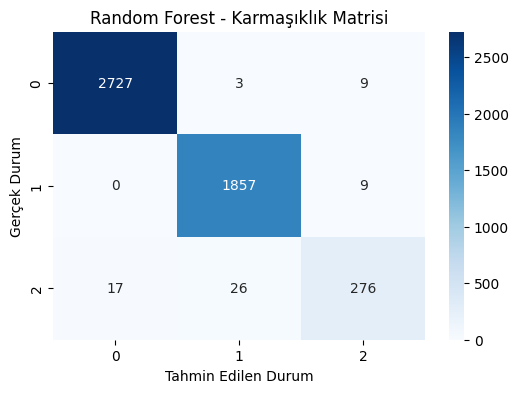

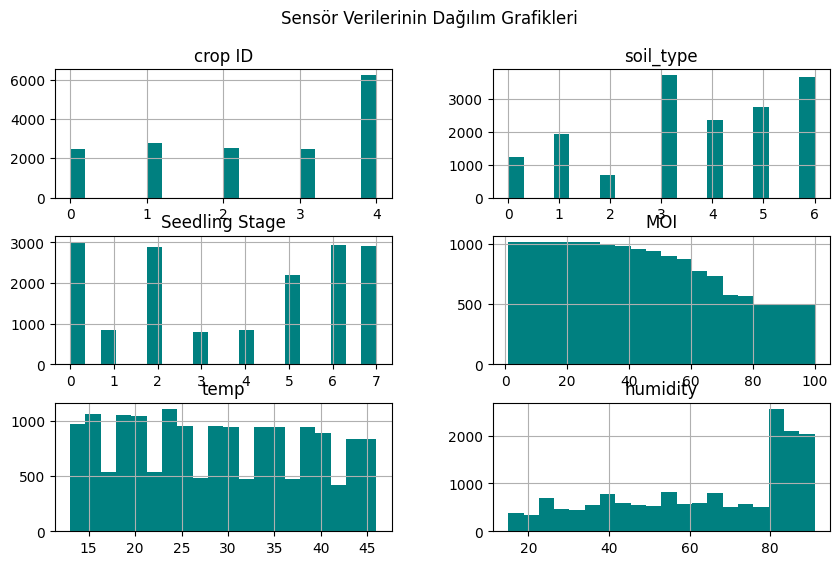

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# ADIM 1: Veri Hazırlığı
dosya_adi = "cropdata_updated.csv"
df = pd.read_csv(dosya_adi)

# Veri setindeki sütunlar
print("Veri setindeki sütunlar:", df.columns.tolist())

# String değerleri sayılara çevir
for column in df.select_dtypes(include=['object']).columns:
    df[column] = LabelEncoder().fit_transform(df[column])

# Boş verileri ortalamayla doldur
df.fillna(df.mean(), inplace=True)

# Hedef sütunu otomatik olarak en son sütun kabul et
hedef_sutun = df.columns[-1]
print(f"Hedef (Tahmin edilecek) Sütun: {hedef_sutun}\n")

X = df.drop(hedef_sutun, axis=1)
y = df[hedef_sutun]

# Verileri ölçeklendirme
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# ADIM 2: Modelleme (3 Farklı Sınıflandırıcı)
models = {
    "J48 (Karar Ağacı)": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "IBk (K-En Yakın Komşu)": KNeighborsClassifier(n_neighbors=5)
}


# ADIM 3: Değerlendirme (10-Fold CV)
print("--- 10-Fold Cross Validation Sonuçları ---\n")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_scaled, y, cv=10, scoring='accuracy')
    print(f"{name} Ortalama Doğruluk (Accuracy): {cv_scores.mean():.4f}")

# En iyi modeli detaylı inceleme (Random Forest)
best_model = models["Random Forest"]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("\n--- En İyi Model (Random Forest) Detaylı Metrikleri ---\n")
print(classification_report(y_test, y_pred))

# Karmaşıklık Matrisi (Confusion Matrix) Görseli
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Karmaşıklık Matrisi')
plt.ylabel('Gerçek Durum')
plt.xlabel('Tahmin Edilen Durum')
plt.show()

# Sensör verilerinin (Sıcaklık, Nem, Toprak Nemi) genel dağılımı
df.drop(hedef_sutun, axis=1).hist(bins=20, figsize=(10, 6), color='teal')
plt.suptitle("Sensör Verilerinin Dağılım Grafikleri")
plt.show()